# Wide Residual Networks on CIFAR-10
Replication of Zagoruyko & Komodakis (2016)

In [21]:
# Cell 1: Imports and config

!pip install pandas matplotlib torchvision

import math
import time
import json
import pickle
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import GradScaler
import torchvision
import torchvision.transforms as transforms

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"
print(f"running on device: {device}, GPU: {gpu_name}")

torch.backends.cudnn.benchmark = True

# Hyperparameters
BATCH_SIZE    = 128
EPOCHS        = 200
BASE_LR       = 0.1
MOMENTUM      = 0.9
WEIGHT_DECAY  = 5e-4
LR_DROP_EPOCHS = [60, 120, 160]
LR_DROP_FACTOR = 0.2
NUM_WORKERS   = 4

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

# 4 configs: (depth, width_multiplier, paper_error_%)
CONFIGS = [
    (28, 10, 4.00),
    (40,  1, 6.85),
    (40,  2, 5.33),
    (40,  4, 4.97),
]

USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print(f"BF16 mixed precision: {USE_BF16}")
print(f"PyTorch version: {torch.__version__}")


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
running on device: cuda, GPU: NVIDIA H100 80GB HBM3
BF16 mixed precision: True
PyTorch version: 2.4.1+cu124


In [22]:
# Cell 2: Data loading
train_transform = transforms.Compose([
    transforms.Pad(4, padding_mode="reflect"),
    transforms.RandomCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True,  download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Files already downloaded and verified
Files already downloaded and verified
Train batches: 391, Test batches: 79


In [23]:
# Cell 3: WideResNet definition

class WideBasicBlock(nn.Module):
    """Pre-activation basic block: BN→ReLU→Conv→BN→ReLU→Conv (He et al. 2016)."""

    def __init__(self, in_ch, out_ch, stride):
        super().__init__()
        self.bn1   = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1,      padding=1, bias=False)

        self.shortcut = None
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)

    def forward(self, x):
        out = F.relu(self.bn1(x), inplace=True)
        # Apply shortcut to the post-BN1 activation so dimensions match
        skip = self.shortcut(out) if self.shortcut is not None else x
        out  = self.conv1(out)
        out  = self.conv2(F.relu(self.bn2(out), inplace=True))
        return out + skip


class WideResNet(nn.Module):
    """
    WRN-n-k for CIFAR-10.
    n: total convolutional layers  (must satisfy (n-4) % 6 == 0)
    k: width multiplier
    """

    def __init__(self, depth, width, num_classes=10):
        super().__init__()
        assert (depth - 4) % 6 == 0, "depth must satisfy (depth-4) % 6 == 0"
        N = (depth - 4) // 6          # blocks per group
        c = [16, 16 * width, 32 * width, 64 * width]

        self.conv0  = nn.Conv2d(3, c[0], 3, stride=1, padding=1, bias=False)
        self.group1 = self._make_group(c[0], c[1], N, stride=1)
        self.group2 = self._make_group(c[1], c[2], N, stride=2)
        self.group3 = self._make_group(c[2], c[3], N, stride=2)
        self.bn_out = nn.BatchNorm2d(c[3])
        self.fc     = nn.Linear(c[3], num_classes)

        self._init_weights()

    @staticmethod
    def _make_group(in_ch, out_ch, num_blocks, stride):
        blocks = [WideBasicBlock(in_ch, out_ch, stride)]
        for _ in range(1, num_blocks):
            blocks.append(WideBasicBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*blocks)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.conv0(x)
        x = self.group1(x)
        x = self.group2(x)
        x = self.group3(x)
        x = F.relu(self.bn_out(x), inplace=True)
        x = x.mean(dim=(2, 3))   # global average pool
        return self.fc(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Quick sanity-check of parameter counts
expected = {(40,1): 0.6e6, (40,2): 2.2e6, (40,4): 8.9e6, (28,10): 36.5e6}
for (d, k, _) in CONFIGS:
    m = WideResNet(d, k)
    p = count_params(m)
    print(f"WRN-{d}-{k}: {p/1e6:.2f}M params  (paper ≈ {expected[(d,k)]/1e6:.1f}M)")
    del m

WRN-28-10: 36.48M params  (paper ≈ 36.5M)
WRN-40-1: 0.56M params  (paper ≈ 0.6M)
WRN-40-2: 2.24M params  (paper ≈ 2.2M)
WRN-40-4: 8.95M params  (paper ≈ 8.9M)


In [24]:
# Cell 4: Training / eval functions

def train_one_epoch(model, loader, optimizer, scaler, scheduler=None):
    model.train()
    total_loss = 0.0
    n = 0
    autocast_dtype = torch.bfloat16 if USE_BF16 else torch.float16
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=autocast_dtype, enabled=torch.cuda.is_available()):
            loss = F.cross_entropy(model(images), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        n += images.size(0)
    return total_loss / n


@torch.no_grad()
def eval_error(model, loader):
    model.eval()
    wrong = 0
    n = 0
    autocast_dtype = torch.bfloat16 if USE_BF16 else torch.float16
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=autocast_dtype, enabled=torch.cuda.is_available()):
            preds = model(images).argmax(dim=1)
        wrong += (preds != labels).sum().item()
        n += labels.size(0)
    return 100.0 * wrong / n


def make_optimizer_and_scheduler(model, epochs):
    optimizer = optim.SGD(
        model.parameters(),
        lr=BASE_LR, momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY, nesterov=True
    )
    # Multiplicative LR schedule: drop by 0.2 at specified epochs
    def lr_lambda(epoch):
        factor = 1.0
        for drop_epoch in LR_DROP_EPOCHS:
            if epoch >= drop_epoch:
                factor *= LR_DROP_FACTOR
        return factor
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler


def train_config(depth, width, epochs, tag):
    """Train one WRN config and return a dict of per-epoch logs."""
    print(f"\n{'='*60}")
    print(f"  {tag}  |  depth={depth}, width={width}, epochs={epochs}")
    print(f"{'='*60}")

    model = WideResNet(depth, width).to(device)
    n_params = count_params(model)
    print(f"  Parameters: {n_params/1e6:.2f}M")

    if int(torch.__version__.split(".")[0]) >= 2:
        try:
            model = torch.compile(model)
            print("  torch.compile: enabled")
        except Exception as e:
            print(f"  torch.compile: skipped ({e})")

    optimizer, scheduler = make_optimizer_and_scheduler(model, epochs)
    scaler = GradScaler("cuda", enabled=torch.cuda.is_available())
    logs = {"train_loss": [], "test_error": [], "epoch_time": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        test_err   = eval_error(model, test_loader)
        scheduler.step()
        elapsed = time.time() - t0

        logs["train_loss"].append(train_loss)
        logs["test_error"].append(test_err)
        logs["epoch_time"].append(elapsed)

        if epoch % 10 == 0 or epoch == 1:
            lr = optimizer.param_groups[0]["lr"]
            print(
                f"  Epoch {epoch:3d}/{epochs}  "
                f"loss={train_loss:.4f}  "
                f"err={test_err:.2f}%  "
                f"lr={lr:.5f}  "
                f"time={elapsed:.1f}s"
            )

    logs["final_test_error"] = logs["test_error"][-1]
    logs["n_params"] = n_params
    print(f"  Final test error: {logs['final_test_error']:.2f}%")
    return logs

In [ ]:
# Cell 5: Smoke test (WRN-40-1 for 2 epochs)

print("Running smoke test: WRN-40-1 for 2 epochs …")
_smoke_model = WideResNet(40, 1).to(device)
_smoke_opt, _smoke_sched = make_optimizer_and_scheduler(_smoke_model, 2)
_smoke_scaler = GradScaler(enabled=torch.cuda.is_available())

for _ep in range(1, 3):
    _t = time.time()
    _loss = train_one_epoch(_smoke_model, train_loader, _smoke_opt, _smoke_scaler)
    _err  = eval_error(_smoke_model, test_loader)
    _smoke_sched.step()
    print(f"  Smoke epoch {_ep}: loss={_loss:.4f}  err={_err:.2f}%  time={time.time()-_t:.1f}s")

del _smoke_model, _smoke_opt, _smoke_sched, _smoke_scaler
print("Smoke test passed; proceed to full training.")

Running smoke test: WRN-40-1 for 2 epochs …
  Smoke epoch 1: loss=1.4311  err=50.75%  time=12.3s
  Smoke epoch 2: loss=0.9800  err=32.45%  time=11.8s
Smoke test passed; proceed to full training.


In [26]:
# Cell 6: Main training loop

all_results = {}   # key: "WRN-{depth}-{width}"

for (depth, width, paper_err) in CONFIGS:
    tag = f"WRN-{depth}-{width}"
    logs = train_config(depth, width, EPOCHS, tag)
    logs["paper_error"] = paper_err
    all_results[tag] = logs

    save_path = f"results_{tag}.pkl"
    with open(save_path, "wb") as f:
        pickle.dump({tag: logs}, f)
    print(f"  Saved → {save_path}")

with open("results_all.pkl", "wb") as f:
    pickle.dump(all_results, f)
print("\nAll results saved to results_all.pkl")


  WRN-28-10  |  depth=28, width=10, epochs=200
  Parameters: 36.48M
  torch.compile: enabled
  Epoch   1/200  loss=1.4949  err=48.14%  lr=0.10000  time=56.8s
  Epoch  10/200  loss=0.3742  err=18.91%  lr=0.10000  time=11.0s
  Epoch  20/200  loss=0.2939  err=14.07%  lr=0.10000  time=11.5s
  Epoch  30/200  loss=0.2760  err=15.27%  lr=0.10000  time=11.6s
  Epoch  40/200  loss=0.2631  err=14.26%  lr=0.10000  time=11.6s
  Epoch  50/200  loss=0.2517  err=13.41%  lr=0.10000  time=11.5s
  Epoch  60/200  loss=0.2501  err=14.33%  lr=0.02000  time=11.4s
  Epoch  70/200  loss=0.0434  err=6.46%  lr=0.02000  time=11.2s
  Epoch  80/200  loss=0.0614  err=7.61%  lr=0.02000  time=10.9s
  Epoch  90/200  loss=0.0621  err=7.51%  lr=0.02000  time=9.5s
  Epoch 100/200  loss=0.0571  err=8.95%  lr=0.02000  time=11.6s
  Epoch 110/200  loss=0.0587  err=7.87%  lr=0.02000  time=11.5s
  Epoch 120/200  loss=0.0557  err=7.91%  lr=0.00400  time=11.4s
  Epoch 130/200  loss=0.0028  err=4.19%  lr=0.00400  time=11.3s
  Ep

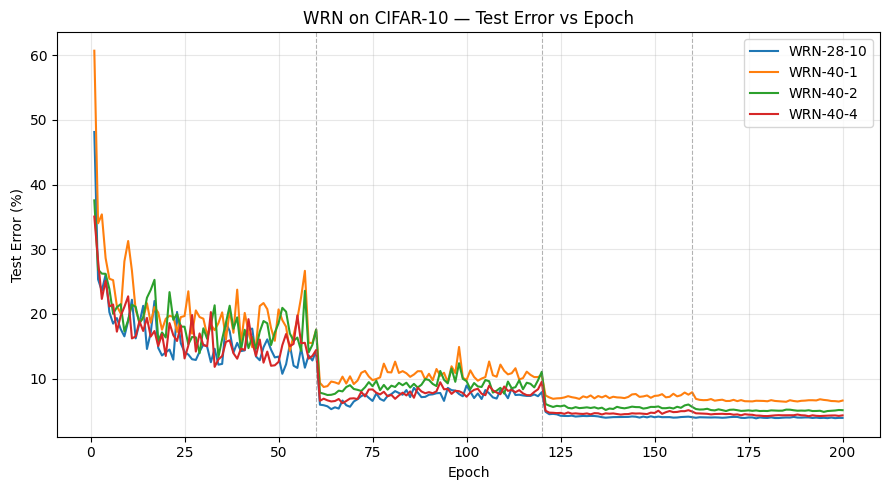

In [27]:
# Cell 8a: Plot: test error vs epoch

fig, ax = plt.subplots(figsize=(9, 5))
for tag, logs in all_results.items():
    ax.plot(range(1, EPOCHS + 1), logs["test_error"], label=tag)
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Error (%)")
ax.set_title("WRN on CIFAR-10: Test Error vs Epoch")
ax.legend()
ax.grid(True, alpha=0.3)
for drop in LR_DROP_EPOCHS:
    ax.axvline(drop, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig("test_error_vs_epoch.png", dpi=150)
plt.show()

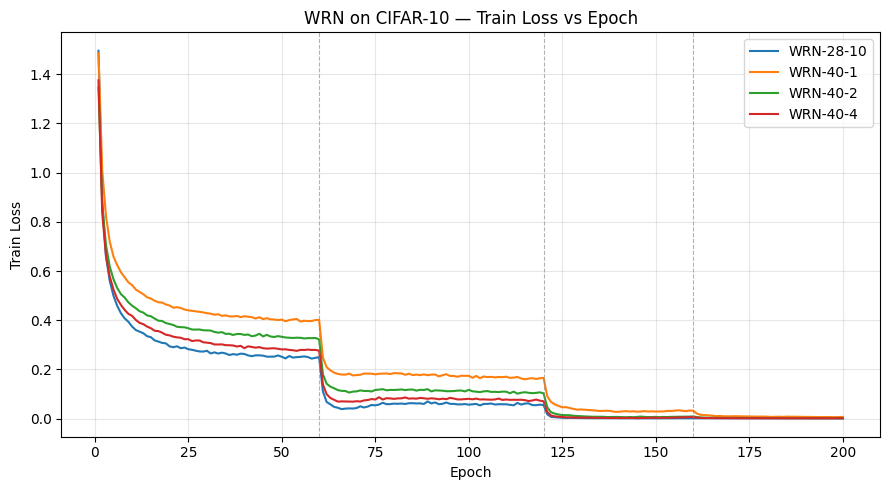

In [28]:
# Cell 8b: Plot: train loss vs epoch

fig, ax = plt.subplots(figsize=(9, 5))
for tag, logs in all_results.items():
    ax.plot(range(1, EPOCHS + 1), logs["train_loss"], label=tag)
ax.set_xlabel("Epoch")
ax.set_ylabel("Train Loss")
ax.set_title("WRN on CIFAR-10: Train Loss vs Epoch")
ax.legend()
ax.grid(True, alpha=0.3)
for drop in LR_DROP_EPOCHS:
    ax.axvline(drop, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig("train_loss_vs_epoch.png", dpi=150)
plt.show()

In [ ]:
# Cell 8c: Scatter: final test error vs parameter count

fig, ax = plt.subplots(figsize=(7, 5))
for tag, logs in all_results.items():
    x = logs["n_params"] / 1e6
    y = logs["final_test_error"]
    ax.scatter(x, y, s=80, zorder=3)
    ax.annotate(tag, (x, y), textcoords="offset points", xytext=(6, 2), fontsize=9)
ax.set_xlabel("Parameters (M)")
ax.set_ylabel("Final Test Error (%)")
ax.set_title("Final Test Error vs Model Size")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("error_vs_params.png", dpi=150)
plt.show()

In [ ]:
# Cell 8d: Summary table

rows = []
for tag, logs in all_results.items():
    rows.append({
        "Config": tag,
        "Params (M)": f"{logs['n_params']/1e6:.2f}",
        "Our Error (%)": f"{logs['final_test_error']:.2f}",
        "Paper Error (%)": f"{logs['paper_error']:.2f}",
        "Delta (%)": f"{logs['final_test_error'] - logs['paper_error']:+.2f}",
        "Total Time (min)": f"{sum(logs['epoch_time'])/60:.1f}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv("summary.csv", index=False)